In [1]:
import duckdb
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [2]:
project_root_path = "../../"
customers_path = project_root_path + "data/customers.parquet"

In [3]:
# Load customers table
customers = duckdb.read_parquet(customers_path)

# Sales
purchase = duckdb.sql("SELECT * FROM customers WHERE event_type = 'purchase'")

The RFM (Recency, Frequency, Monetary value) method is used to describe the potential of a customer.
- Recency: How recently did a customer make a purchase ?
- Frequency: How often did he purchase (ever, per month) ?
- Monetary value: How much money do he spent (in total, per order) ?

`Customers groups`

<ins>Inactive:</ins> Haven't purchase anything during last 3 month

<ins>New:</ins> Made a first purchase this month

<ins>Loyal silver:</ins> Made between 5 and 9 purchases

<ins>Loyal gold:</ins> Made between 10 and 19 purchases

<ins>Loyal platinum:</ins> Made more than 20 purchases

In [4]:
# Number of orders, total and average price per order
rfm = duckdb.sql("""
SELECT
    user_id,
    -- Calculate exact days between dates, divide by avg month length, and round to 2 decimals
    ROUND(
        DATE_DIFF('day', MAX(event_time)::DATE, CAST('2023-02-28' AS DATE)) / 30.44,
        2
    ) AS last_purchase,
    COUNT(DISTINCT user_session) AS nb_orders,
    SUM(price) AS total_spent,
    AVG(price) AS avg_spent
FROM
    purchase
GROUP BY
    user_id
""")

# Assining a group to every customer
rfm_groups = duckdb.sql(
"""
SELECT *,
    CASE
        WHEN last_purchase >= 3 THEN 'inactive'
        WHEN last_purchase = 0 AND nb_orders = 1 THEN 'new'
        WHEN nb_orders >= 5 AND nb_orders < 10 THEN 'loyal_silver'
        WHEN nb_orders >= 10 AND nb_orders < 20 THEN 'loyal_gold'
        WHEN nb_orders >= 20 THEN 'loyal_platinum'
        ELSE NULL
    END AS groups
FROM rfm
""")

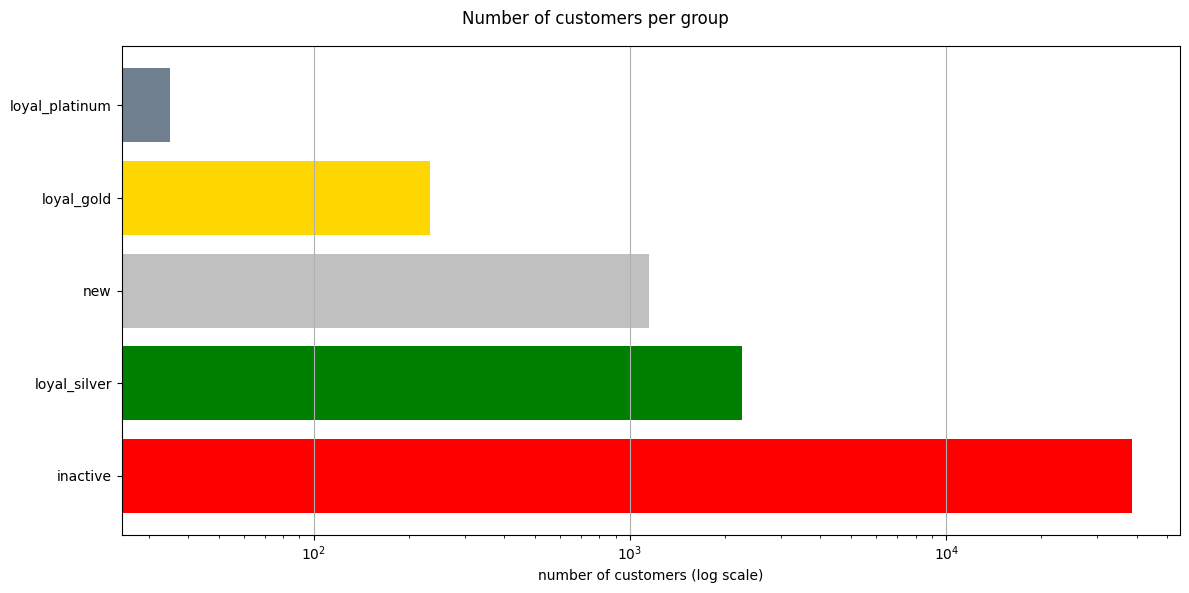

In [5]:
# Count the number of customers per group
customers_per_group = duckdb.sql(
"""
SELECT groups, COUNT(user_id) AS nb_customers
FROM rfm_groups
WHERE groups IS NOT NULL
GROUP BY groups
ORDER BY nb_customers DESC
""").fetchnumpy()

fig, ax = plt.subplots(figsize=(12,6))
fig.suptitle("Number of customers per group")

ax.barh(customers_per_group["groups"], customers_per_group["nb_customers"],
        color=['red', 'green', 'silver', 'gold', 'slategrey'])
ax.set_xscale('log', base=10)

ax.set_xlabel("number of customers (log scale)")
ax.grid(axis='x')

plt.tight_layout()
plt.show()

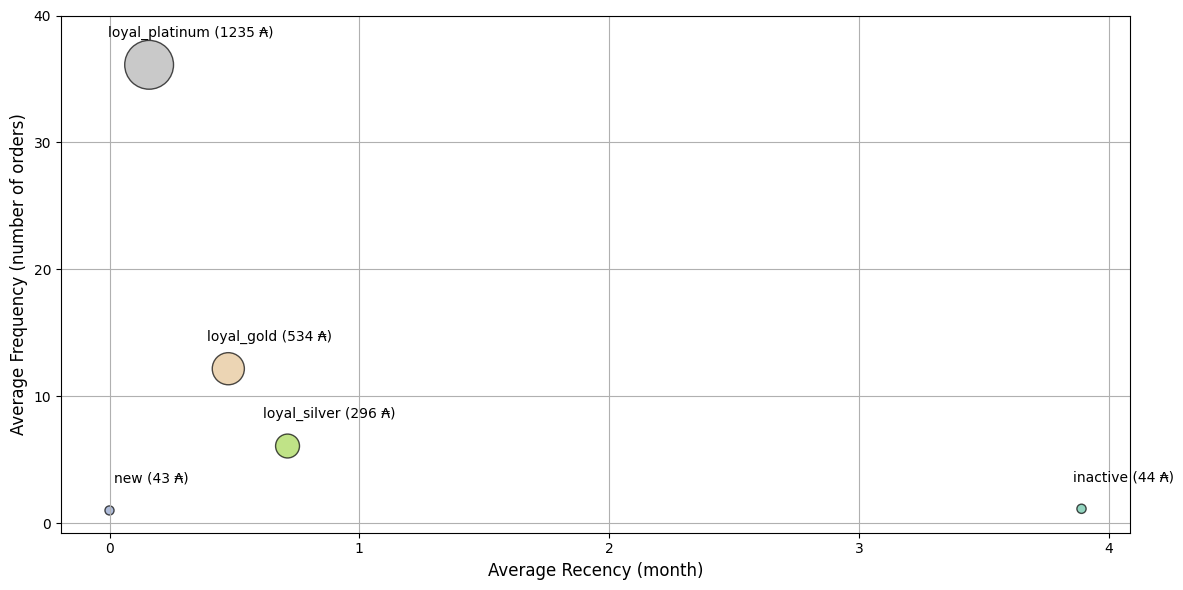

In [6]:
# Calculate average metrics per group for the bubble chart
group_stats = duckdb.sql(
"""
SELECT
        groups,
        AVG(nb_orders) AS avg_nb_orders,
        AVG(total_spent) AS avg_total_spent,
        AVG(last_purchase) AS avg_month_last_purchase
FROM rfm_groups
WHERE groups IS NOT NULL
GROUP BY groups
""").fetchnumpy()

fig, ax = plt.subplots(figsize=(12, 6))

bubble_sizes = group_stats["avg_total_spent"]

scatter = ax.scatter(
    group_stats["avg_month_last_purchase"],
    group_stats["avg_nb_orders"],
    s=bubble_sizes,
    alpha=0.7,
    edgecolors="black",
    c=range(len(group_stats["groups"])),
    cmap="Set2"
)

for i, txt in enumerate(group_stats["groups"]):
    ax.annotate(
        f"{txt} ({int(group_stats["avg_total_spent"][i])} ₳)",
        (group_stats["avg_month_last_purchase"][i], group_stats["avg_nb_orders"][i]),
        textcoords="offset points",
        xytext=(30, 20),
        ha='center',
        fontsize=10
    )

ax.set_xlabel("Average Recency (month)", fontsize=12)
ax.set_ylabel("Average Frequency (number of orders)", fontsize=12)
ax.set_xticks(range(0, 5))
ax.set_yticks(range(0, 50, 10))
ax.grid()

plt.tight_layout()
plt.show()

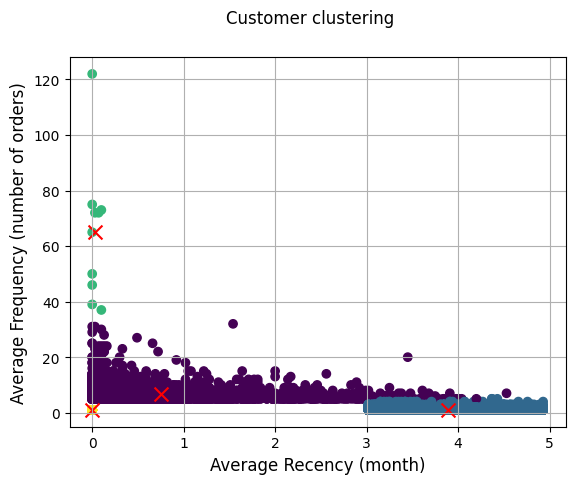

In [32]:
matrix = rfm_groups.filter("groups IS NOT NULL").project("nb_orders, last_purchase").df().to_numpy()
kmean = KMeans(n_clusters=4, n_init=42)
labels = kmean.fit_predict(matrix)
centroids = kmean.cluster_centers_

fig, ax = plt.subplots()

fig.suptitle("Customer clustering")

ax.scatter(matrix[:, 1], matrix[:, 0],  c=labels)
ax.scatter(centroids[:, 1], centroids[:, 0], c='red', marker='x', s=100)

ax.set_xlabel("Average Recency (month)", fontsize=12)
ax.set_ylabel("Average Frequency (number of orders)", fontsize=12)

ax.grid()

plt.show()